##### Useful info

https://stackoverflow.com/questions/47664061/how-to-apply-polynomial-transformation-to-subset-of-features-in-scikitlearn

https://stackoverflow.com/questions/34274598/does-gridsearchcv-store-all-the-scores-for-all-parameter-combinations

https://stats.stackexchange.com/questions/110599/how-to-get-both-mse-and-r2-from-a-sklearn-gridsearchcv


In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 8))
np.set_printoptions(precision=4, suppress=False)
# please show all columns
pd.set_option("display.max_columns", 60)
import seaborn as sns
sns.set()

In [2]:
# Import sklearn stuff
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import r2_score, mean_squared_error, make_scorer

from sklearn.model_selection import train_test_split 
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline


In [3]:
# read cleaned data
dfModelAll = pd.read_csv('../local/data/LBNL_openpv_tts_data/ModelData.csv', index_col='row_id')

In [4]:
dfModelAll.reset_index(inplace=True)

In [5]:
dfModelAll.head()

,row_id,num_days,size_kw,state,cost_per_watt,scaleSize
0,1,0,2.2824,CA,10.734315,0
1,2,21,1.8504,CA,11.108701,0
2,4,26,2.3076,CA,8.667013,0
3,6,84,2.3316,CA,13.270286,0
4,7,111,0.9300,CA,14.654839,0


In [6]:
dfModelAll.drop('row_id', axis='columns', inplace=True)

In [7]:
dfModelAll = dfModelAll.astype({'num_days' : np.float, 'state' : 'category'}); dfModelAll.head()

,num_days,size_kw,state,cost_per_watt,scaleSize
0,0.0,2.2824,CA,10.734315,0
1,21.0,1.8504,CA,11.108701,0
2,26.0,2.3076,CA,8.667013,0
3,84.0,2.3316,CA,13.270286,0
4,111.0,0.9300,CA,14.654839,0


In [25]:
dfModelAll.index.name = 'row'


In [26]:
dfModelAll.head()

,num_days,size_kw,state,cost_per_watt,scaleSize
row,,,,,
0,0.0,2.2824,CA,10.734315,0
1,21.0,1.8504,CA,11.108701,0
2,26.0,2.3076,CA,8.667013,0
3,84.0,2.3316,CA,13.270286,0
4,111.0,0.9300,CA,14.654839,0


In [8]:
dfModelAll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364212 entries, 0 to 364211
Data columns (total 5 columns):
num_days         364212 non-null float64
size_kw          364212 non-null float64
state            364212 non-null category
cost_per_watt    364212 non-null float64
scaleSize        364212 non-null int64
dtypes: category(1), float64(3), int64(1)
memory usage: 11.5 MB


In [27]:
dfModelAll.to_csv('../local/data/LBNL_openpv_tts_data/ModelAll.csv')

In [9]:
dfModelAll.state.unique()

[CA, OR, AZ, NY, MN, ..., MD, CT, FL, NM, AR]
Length: 19
Categories (19, object): [CA, OR, AZ, NY, ..., CT, FL, NM, AR]

In [10]:
dfMod = dfModelAll.sample(frac=0.1)

In [11]:
len(dfModelAll), len(dfMod)

(364212, 36421)

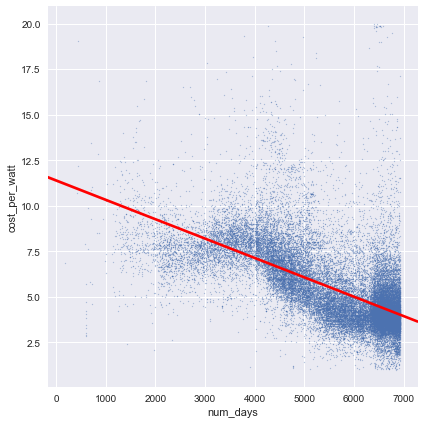

In [12]:
sns.lmplot('num_days', 'cost_per_watt', dfMod, 
           size=6, markers='.', 
           scatter_kws={'alpha' : 0.4, 's' : 7},
           line_kws={'color':'red'})

#### Set up a pipeline

In [13]:
# set up to model one feature (column vectors for both X and y)
X = dfMod[['num_days']].values
y = dfMod[['cost_per_watt']].values
X.shape, y.shape

((36421, 1), (36421, 1))

In [14]:
# Setup the pipeline steps: steps
steps = [('scaler', StandardScaler()),
         ('poly', PolynomialFeatures()),
         ('LR', LinearRegression())]

# Create the pipeline: pipeline 
pipeline = Pipeline(steps)

In [15]:
pipeline.get_params().keys()

dict_keys(['memory', 'steps', 'scaler', 'poly', 'LR', 'scaler__copy', 'scaler__with_mean', 'scaler__with_std', 'poly__degree', 'poly__include_bias', 'poly__interaction_only', 'LR__copy_X', 'LR__fit_intercept', 'LR__n_jobs', 'LR__normalize'])

In [16]:
# Specify the hyperparameter space; .
# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 10)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=0)

# Create the GridSearchCV object: gm_cv
gs_cv = GridSearchCV(pipeline, param_grid, cv=3, return_train_score=True)

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(r2))

Best parameters: {'poly__degree': 9}
test R squared: 0.45485052029399553


In [17]:
# this will show the results data structure
gs_cv.cv_results_

{'mean_fit_time': array([0.0013, 0.002 , 0.0077, 0.004 , 0.0037, 0.0053, 0.0074, 0.007 ,
        0.0077]),
 'mean_score_time': array([0.001 , 0.002 , 0.001 , 0.001 , 0.001 , 0.0007, 0.001 , 0.001 ,
        0.001 ]),
 'mean_test_score': array([0.3899, 0.3981, 0.4155, 0.4253, 0.4257, 0.4348, 0.4338, 0.4349,
        0.4359]),
 'mean_train_score': array([0.39  , 0.3983, 0.4159, 0.4258, 0.4263, 0.4367, 0.4369, 0.4372,
        0.4373]),
 'param_poly__degree': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9],
              mask=[False, False, False, False, False, False, False, False,
                    False],
        fill_value='?',
             dtype=object),
 'params': [{'poly__degree': 1},
  {'poly__degree': 2},
  {'poly__degree': 3},
  {'poly__degree': 4},
  {'poly__degree': 5},
  {'poly__degree': 6},
  {'poly__degree': 7},
  {'poly__degree': 8},
  {'poly__degree': 9}],
 'rank_test_score': array([9, 8, 7, 6, 5, 3, 4, 2, 1]),
 'split0_test_score': array([0.3934, 0.4033, 0.4178, 0.4281, 0.42

#### The pipeline above is working.  Bext step is to add a scorer that produces multiple scores.  Example below.

#### this is example code from SO; it's outdated but still works

In [18]:
# from sklearn.metrics import r2_score, mean_squared_error, make_scorer
# from sklearn.grid_search import GridSearchCV
# from sklearn.linear_model import Ridge

# def MSE(y_true,y_pred):
#     mse = mean_squared_error(y_true, y_pred)
#     print('MSE: %2.3f' % mse)
#     return mse

# def R2(y_true,y_pred):    
#      r2 = r2_score(y_true, y_pred)
#      print( 'R2: %2.3f' % r2)
#      return r2

# def two_score(y_true,y_pred):    
#     MSE(y_true,y_pred) #set score here and not below if using MSE in GridCV
#     score = R2(y_true,y_pred)
#     return score

# def two_scorer():
#     return make_scorer(two_score, greater_is_better=True) # change for false if using MSE

# model = Ridge()
# param_grid = {'alpha':[0.1,1,10]}
# X_train = [[1,2],[1,5],[-3,2],[3,7],[-1,1],[0,-1]]
# y_train = [1,0,1,0,3,5]
# grid = GridSearchCV(model, param_grid, scoring=two_scorer())

# grid.fit(X_train, y_train)
# best_params = grid.best_params_
# model = grid.best_estimator_
# score = grid.best_score_
# for item in grid.grid_scores_:
#     print( "\t%s %s %s" % ('\tGRIDSCORES\t',  "R" , item))
# print( '%s\tHP\t%s\t%f' % ("R" , str(best_params), abs(score)))
# # output is here

In [19]:
r2_score

<function sklearn.metrics.regression.r2_score>

#### instead of defining your own scorer to track multiple metrics, you can hand gridsearchcv a list of scoring fns to use (but you can only use the ones they bless).  the other way is to pass a dictionary...

In [20]:
def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Specify the hyperparameter space; .
# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 11)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=0)

# Create the GridSearchCV object: gm_cv
#####################################################################################################
### this works: gs_cv = GridSearchCV(pipeline, param_grid, cv=3, scoring=two_scorer(), return_train_score=True)
######################################################################################################

scoring = {'Rsquared': 'r2',
           'RMSE': make_scorer(RMSE, greater_is_better=False) }


gs_cv = GridSearchCV(pipeline, param_grid, cv=3, 
                     scoring=scoring, return_train_score=True,
                     refit='Rsquared')

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(r2))

gs_cv.cv_results_

Best parameters: {'poly__degree': 10}
test R squared: 0.454537451984413


{'mean_fit_time': array([0.0037, 0.0033, 0.0023, 0.0023, 0.002 , 0.0043, 0.0047, 0.0057,
        0.0077, 0.01  ]),
 'mean_score_time': array([0.003 , 0.001 , 0.001 , 0.001 , 0.0017, 0.0017, 0.0023, 0.0013,
        0.002 , 0.002 ]),
 'mean_test_RMSE': array([-1.6737, -1.6624, -1.6381, -1.6243, -1.6238, -1.6108, -1.6123,
        -1.6107, -1.6092, -1.6085]),
 'mean_test_Rsquared': array([0.3899, 0.3981, 0.4155, 0.4253, 0.4257, 0.4348, 0.4338, 0.4349,
        0.4359, 0.4364]),
 'mean_train_RMSE': array([-1.6736, -1.6622, -1.6377, -1.6237, -1.6231, -1.6082, -1.6079,
        -1.6075, -1.6073, -1.6072]),
 'mean_train_Rsquared': array([0.39  , 0.3983, 0.4159, 0.4258, 0.4263, 0.4367, 0.4369, 0.4372,
        0.4373, 0.4374]),
 'param_poly__degree': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value='?',
             dtype=object),
 'params': [{'poly__degree': 1},
  {'

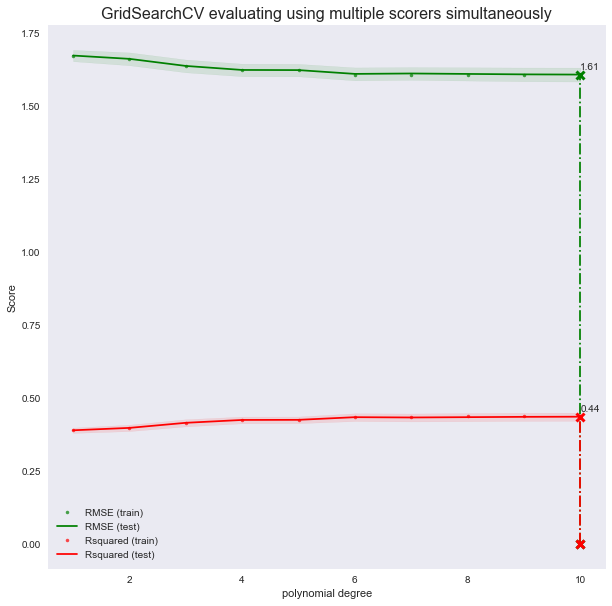

In [21]:
results = gs_cv.cv_results_

fig, ax = plt.subplots(figsize=(10, 10))
plt.title("GridSearchCV evaluating using multiple scorers simultaneously", fontsize=16)

plt.xlabel("polynomial degree")
plt.ylabel("Score")

# I think Seaborn ignores this...
plt.grid(True)

###            two__underscores
X_axis = np.array(results['param_poly__degree'].data, dtype=float)

for scorer, color in zip(sorted(scoring), ['g', 'r']):
    for sample, style in (('train', '.'), ('test', '-')):
        sample_score_mean = np.abs(results['mean_%s_%s' % (sample, scorer)])
        sample_score_std = results['std_%s_%s' % (sample, scorer)]
        ax.fill_between(X_axis, sample_score_mean - sample_score_std,
                        sample_score_mean + sample_score_std,
                        alpha=0.1 if sample == 'test' else 0, color=color)
        ax.plot(X_axis, sample_score_mean, style, color=color,
                alpha=1 if sample == 'test' else 0.7,
                label="%s (%s)" % (scorer, sample))

    best_index = np.abs(np.nonzero(results['rank_test_%s' % scorer] == 1)[0][0])
    best_score = np.abs(results['mean_test_%s' % scorer][best_index])

    # Plot a dotted vertical line at the best score for that scorer marked by x
    ax.plot([X_axis[best_index], ] * 2, [0, best_score],
            linestyle='-.', color=color, marker='x', markeredgewidth=3, ms=8)

    # Annotate the best score for that scorer
    ax.annotate("%0.2f" % best_score,
                (X_axis[best_index], best_score + 0.015))

plt.legend(loc="best")
plt.grid(False)
plt.show();

#### These are the available metrics for multi-metric scoring
```
ValueError: 'r2_score' is not a valid scoring value. Valid options are 
['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'completeness_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'mutual_info_score', 'neg_log_loss', 'neg_mean_absolute_error', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'normalized_mutual_info_score', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'recall', 'recall_macro', 'recall_micro', 'recall_samples', 'recall_weighted', 'roc_auc', 'v_measure_score']
```